**To identify the criteria to approve loans for an individual customer such that the likelihood of the loan delinquency is minimized**

**Key questions to be answered**
What are the factors that drive the behavior of loan delinquency?

**Dataset**
* `ID`: Customer ID
* `isDelinquent` : indicates whether the customer is delinquent or not (1 => Yes, 0 => No)
* `term`: Loan term in months
* `gender`: Gender of the borrower
* `age`: Age of the borrower
* `purpose`: Purpose of Loan
* `home_ownership`: Status of borrower's home
* `FICO`: FICO (i.e. the bureau score) of the borrower

**Domain Information**
* Transactor – A person who pays his due amount balance full and on time.
* Revolver – A person who pays the minimum due amount but keeps revolving his balance and does not pay the full amount.
* Delinquent - Delinquency means that you are behind on payments, a person who fails to pay even the minimum due amount.
* Defaulter – Once you are delinquent for a certain period your lender will declare you to be in the default stage.
* Risk Analytics – A wide domain in the financial and banking industry, basically analyzing the risk of the customer.


**Import Libraries**

In [1]:
# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
)

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings("ignore")

**Read Delinquent Dataset**

In [2]:
data = pd.read_csv("data/21_Loan_Delinquent_Dataset.csv")

In [3]:
# copying data to another varaible to avoid any changes to original data
loan = data.copy()

**Review the dataset**

In [4]:
loan.head()

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
0,1,1,36 months,Female,House,Mortgage,>25,300-500
1,2,0,36 months,Female,House,Rent,20-25,>500
2,3,1,36 months,Female,House,Rent,>25,300-500
3,4,1,36 months,Female,Car,Mortgage,>25,300-500
4,5,1,36 months,Female,House,Rent,>25,300-500


In [5]:
loan.tail()

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
11543,11544,0,60 months,Male,other,Mortgage,>25,300-500
11544,11545,1,36 months,Male,House,Rent,20-25,300-500
11545,11546,0,36 months,Female,Personal,Mortgage,20-25,>500
11546,11547,1,36 months,Female,House,Rent,20-25,300-500
11547,11548,1,36 months,Male,Personal,Mortgage,20-25,300-500


**Observations**

- `ID` this is sequence id, can be removed
- `isDelinquent` is the boolean Target Variable
- `term` we have to find out how many unique values are there
- `age` is given as range
- `FICO` is give as range

**Shape of the dataset**

In [6]:
loan.shape

(11548, 8)

* The dataset has 11548 rows and 8 columns of data

**Data Types**

In [7]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              11548 non-null  int64 
 1   isDelinquent    11548 non-null  int64 
 2   term            11548 non-null  object
 3   gender          11548 non-null  object
 4   purpose         11548 non-null  object
 5   home_ownership  11548 non-null  object
 6   age             11548 non-null  object
 7   FICO            11548 non-null  object
dtypes: int64(2), object(6)
memory usage: 721.9+ KB


**All Dependent variable are given as object**

**Statistical Summary**

In [8]:
loan.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,11548.0,NaN,NaN,NaN,5774.5,3333.764789,1.0,2887.75,5774.5,8661.25,11548.0
isDelinquent,11548.0,NaN,NaN,NaN,0.668601,0.470737,0.0,0.0,1.0,1.0,1.0
term,11548,2,36 months,10589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,11548,2,Male,6555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,11548,7,House,6892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_ownership,11548,3,Mortgage,5461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,11548,2,20-25,5888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FICO,11548,2,300-500,6370,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations-**   

* Most of the loans are for a 36-month term loan.
* More males have applied for loans than females.
* Most loan applications are for house loans.
* Most customers have either mortgaged their houses.
* Mostly customers in the age group 20-25 have applied for a loan.
* Most customers have a FICO score between 300 and 500.

**Dropping the ID column**

In [9]:
loan.drop(["ID"], axis=1, inplace=True)

****Check for Missing Values****

In [10]:
loan.isnull().sum()

isDelinquent      0
term              0
gender            0
purpose           0
home_ownership    0
age               0
FICO              0
dtype: int64

* There are no missing vaues in out dataset

**Visual Analysis**

In [11]:
def target_distribution_by_category(data, x_col, hue_col, colormap='tab20', figsize=(6, 4), title=None):
    """
    Plots a stacked bar chart showing percentage distribution of hue_col within each x_col category,
    with percentage labels on each segment.
    """
    # Group and calculate percentages
    grouped = data.groupby([x_col, hue_col]).size().unstack(fill_value=0)
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

    # Plot
    ax = percentages.plot(kind='bar', stacked=True, figsize=figsize, colormap=colormap)

    # Add percentage labels
    for i, (index, row) in enumerate(percentages.iterrows()):
        cum_height = 0
        for j, value in enumerate(row):
            if value > 0:
                ax.text(
                    i,                      # x position
                    cum_height + value / 2, # y position (middle of the bar segment)
                    f'{value:.1f}%',        # label text
                    ha='center', va='center', fontsize=8, color='white'
                )
                cum_height += value

    plt.ylabel('Percentage')
    plt.title(title or f'{x_col} Distribution by {hue_col} (Stacked Percentage)')
    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


**Delinquency by Loan Term**

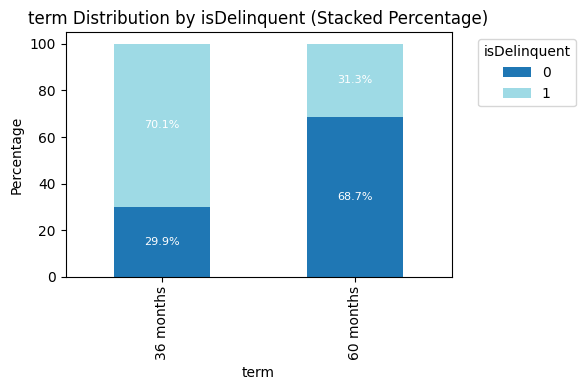

In [12]:
target_distribution_by_category(loan, 'term', 'isDelinquent')

*36 months loan tennure has higher percentage of delinquints*

**Delinquency by Gender**

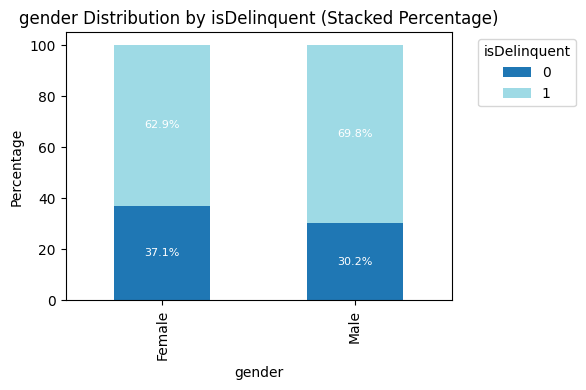

In [13]:
target_distribution_by_category(loan, 'gender', 'isDelinquent')

*Males have higher percentage of delinquency*

**Home Ownership vs Delinquency**

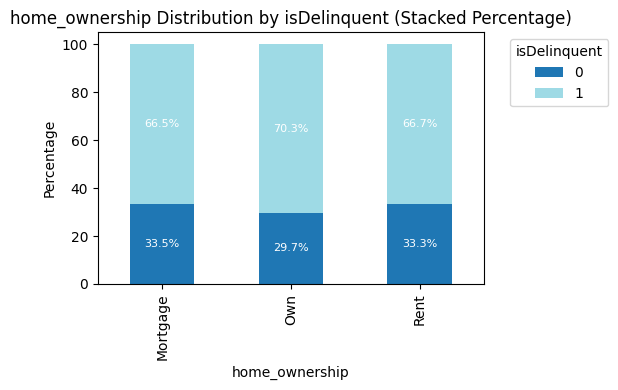

In [14]:
target_distribution_by_category(loan, 'home_ownership', 'isDelinquent')


*Surprisingly folks who own houses, have higher percentage of delinquency compared to mortgage and rent*

**Purpose vs Delinquency**

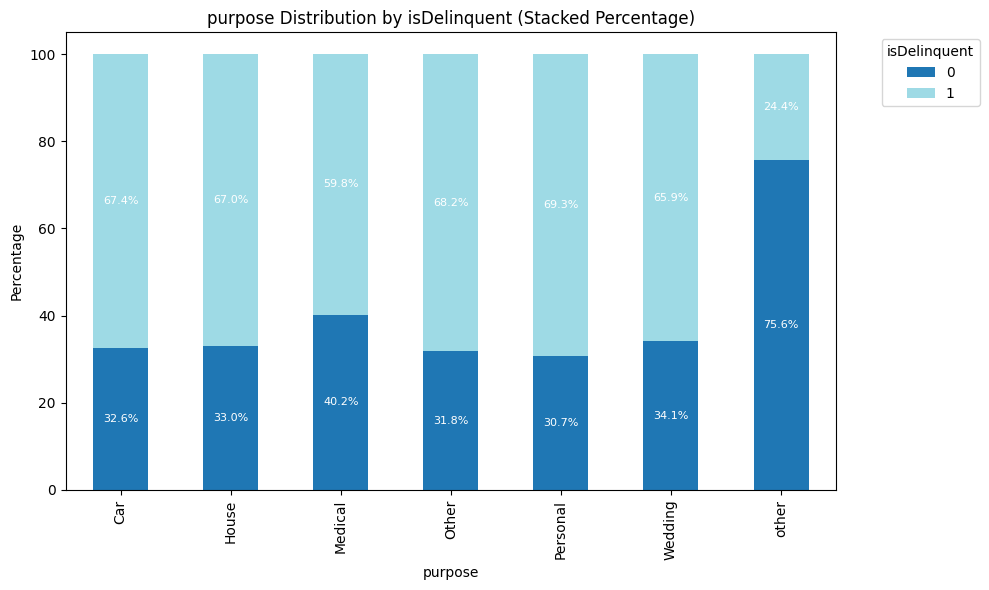

In [15]:
target_distribution_by_category(loan, 'purpose', 'isDelinquent',figsize=(10, 6))

*Most of the delinquency is from Personal Loans, then House and Car*

**Age vs Delinquency**

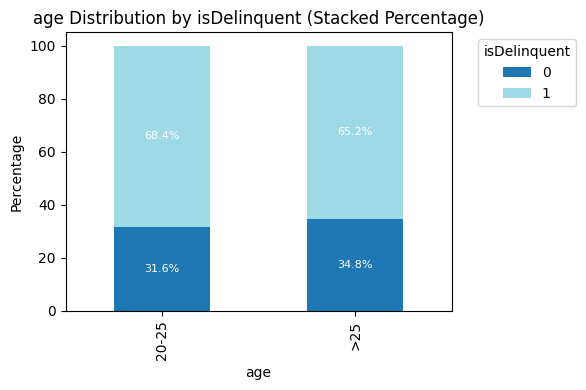

In [16]:
target_distribution_by_category(loan, 'age', 'isDelinquent')

*There is higher percentage if delinquency amount 20-25 age group compared to >25 group*

**FICO vs Delinquency**

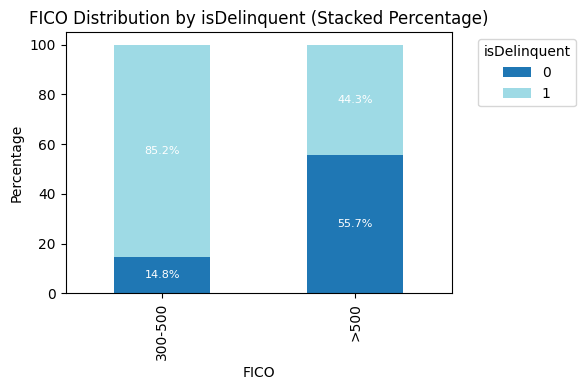

In [17]:
target_distribution_by_category(loan, 'FICO', 'isDelinquent')

*People with lower FICO score have higher chance of delinquency*

**Data Cleaning**

In [18]:
loan.purpose.value_counts()

purpose
House       6892
Car         2080
Other        928
Personal     892
Wedding      408
Medical      266
other         82
Name: count, dtype: int64

*We can merge `other` with `Other`*

In [19]:
loan["purpose"].replace("other", "Other", inplace=True)
loan.purpose.value_counts()

purpose
House       6892
Car         2080
Other       1010
Personal     892
Wedding      408
Medical      266
Name: count, dtype: int64

**Model Building**

***Decision Tree***

In [20]:
# Define features and target variable
X = loan.drop(["isDelinquent"], axis=1)
y = loan["isDelinquent"]

In [21]:
# encoding the categorical variables
X = pd.get_dummies(X, drop_first=True)
X.head()

,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500
0,False,False,True,False,False,False,False,False,False,True,False
1,False,False,True,False,False,False,False,False,True,False,True
2,False,False,True,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,True,False
4,False,False,True,False,False,False,False,False,True,True,False


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

In [23]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 6928
Number of rows in test data = 4620


In [24]:
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Percentage of classes in training set:
isDelinquent
1    0.677396
0    0.322604
Name: proportion, dtype: float64
Percentage of classes in test set:
isDelinquent
1    0.655411
0    0.344589
Name: proportion, dtype: float64


**Build Decision Tree Model**

**Model evaluation criterion**

**Model can make wrong predictions as:**
 
1. Predicting a customer will not be behind on payments (Non-Delinquent) but in reality the customer would be behind on payments. False Negative. Model misses Risky Customer, leading to financial loss. This is often considered more costly. 
2. Predicting a customer will be behind on payments (Delinquent) but in reality the customer would not be behind on payments (Non-Delinquent). False Positive

**How to reduce this loss i.e need to reduce False Negatives?**
*  `recall` should be maximized, the greater the recall higher the chances of minimizing the false negatives.

**Important Helper Functions**
* The model_performance_classification_sklearn function will be used to check the model performance of models. 
* The make_confusion_matrix function will be used to plot confusion matrix.

In [25]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [26]:
def confusion_matrix_sklearn(model, predictors, y_actual):
    """
    Generates a labeled confusion matrix heatmap.

    Parameters:
    - model: trained classifier
    - predictors: feature matrix to predict on (can be train, test, or validation)
    - y_actual: true labels corresponding to X
    """
    # Predict labels
    y_predict = model.predict(predictors)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                             columns=["Predicted - No", "Predicted - Yes"])

    # Annotate with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(cm.shape)

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

#### 1. Build Decision Tree Model with Default Parameters

In [27]:
model = DecisionTreeClassifier(criterion="gini", random_state=1)
model.fit(X_train, y_train)
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

**Model Performance**

In [28]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,0.855514,0.9088,0.881563,0.894974


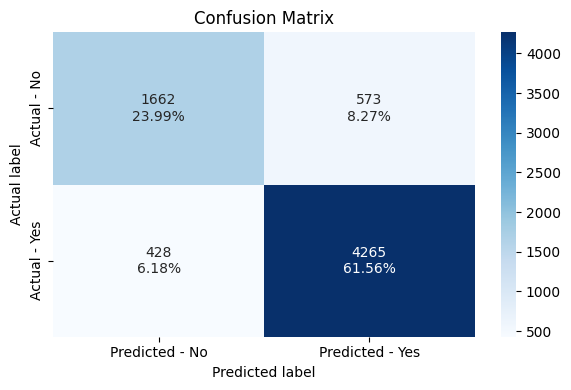

In [29]:
confusion_matrix_sklearn(model, X_train, y_train)

**Checking model performance on test set**

In [30]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.843723,0.897292,0.868606,0.882716


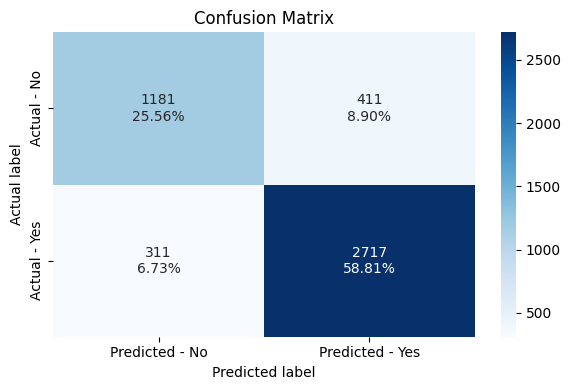

In [31]:
confusion_matrix_sklearn(model, X_test, y_test)

*Model is giving good and generalized results on training and test set.*

**Decision Tree**

In [32]:
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['term_60 months', 'gender_Male', 'purpose_House', 'purpose_Medical', 'purpose_Other', 'purpose_Personal', 'purpose_Wedding', 'home_ownership_Own', 'home_ownership_Rent', 'age_>25', 'FICO_>500']


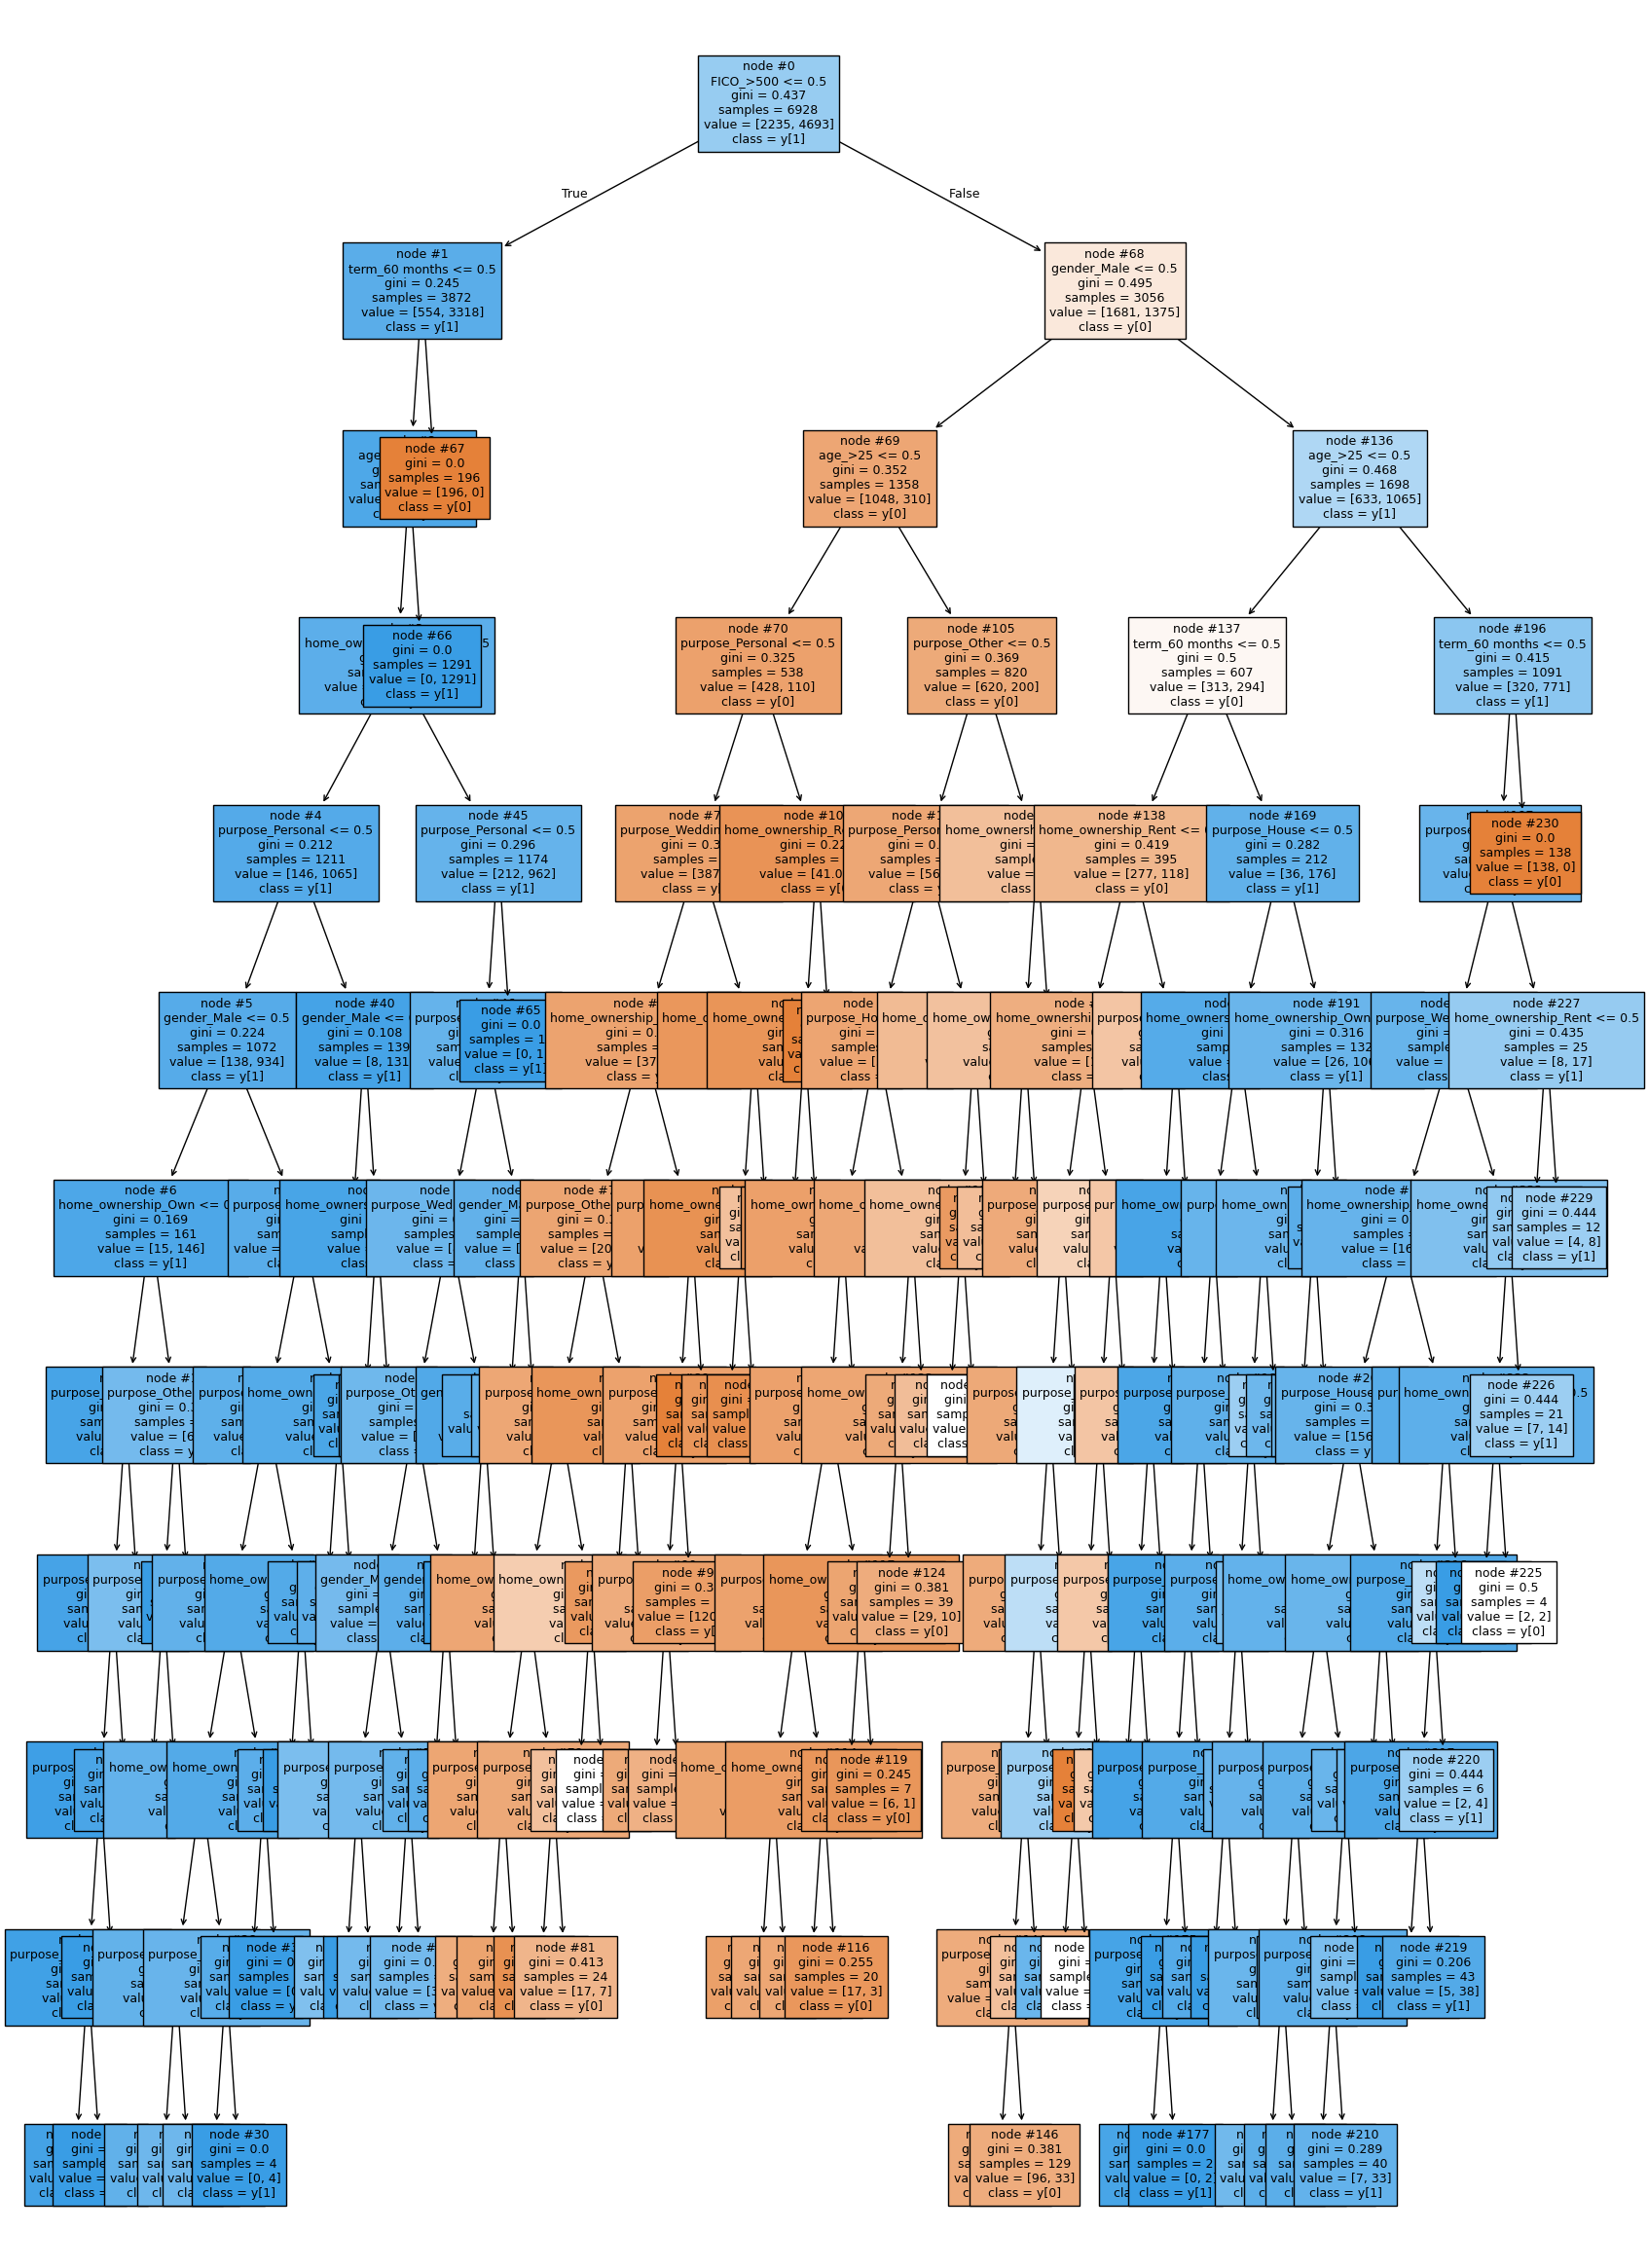

In [33]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [34]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model, feature_names=feature_names, show_weights=True))

|--- FICO_>500 <= 0.50
|   |--- term_60 months <= 0.50
|   |   |--- age_>25 <= 0.50
|   |   |   |--- home_ownership_Rent <= 0.50
|   |   |   |   |--- purpose_Personal <= 0.50
|   |   |   |   |   |--- gender_Male <= 0.50
|   |   |   |   |   |   |--- home_ownership_Own <= 0.50
|   |   |   |   |   |   |   |--- purpose_Medical <= 0.50
|   |   |   |   |   |   |   |   |--- purpose_House <= 0.50
|   |   |   |   |   |   |   |   |   |--- purpose_Other <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- purpose_Wedding <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [1.00, 18.00] class: 1
|   |   |   |   |   |   |   |   |   |   |--- purpose_Wedding >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 9.00] class: 1
|   |   |   |   |   |   |   |   |   |--- purpose_Other >  0.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 14.00] class: 1
|   |   |   |   |   |   |   |   |--- purpose_House >  0.50
|   |   |   |   |   |   |   |   |   |--- weight

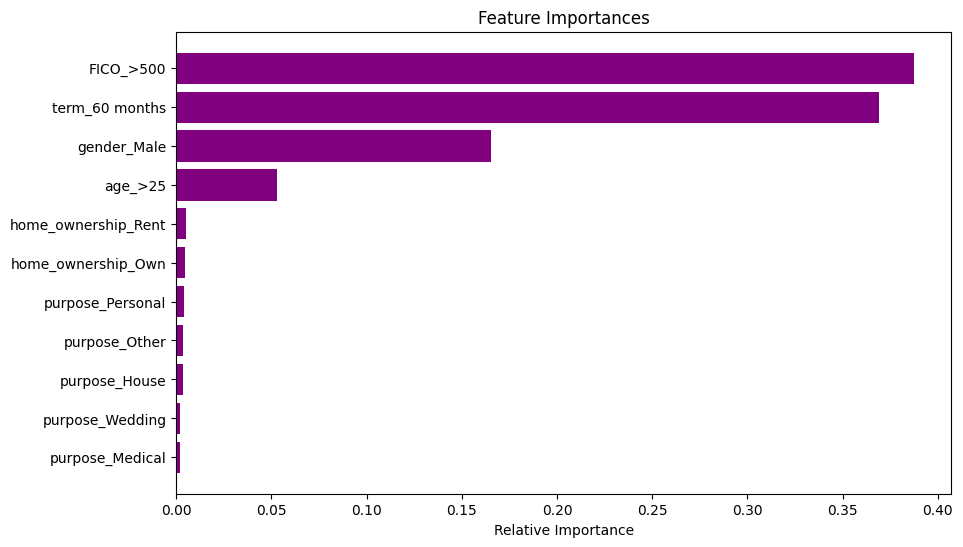

In [35]:
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="purple", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* FICO score, duration of loan and gender are the top 3 important features.

#### 2. Using GridSearch for Hyperparameter tuning of our tree model 

In [36]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from

parameters = {
    "max_depth": [np.arange(2, 50, 5), None],
    "criterion": ["entropy", "gini"],
    "splitter": ["best", "random"],
    "min_impurity_decrease": [0.000001, 0.00001, 0.0001],
}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

estimator.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0001,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

**Checking performance on training set**

In [37]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    estimator, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.855225,0.910079,0.880256,0.894919


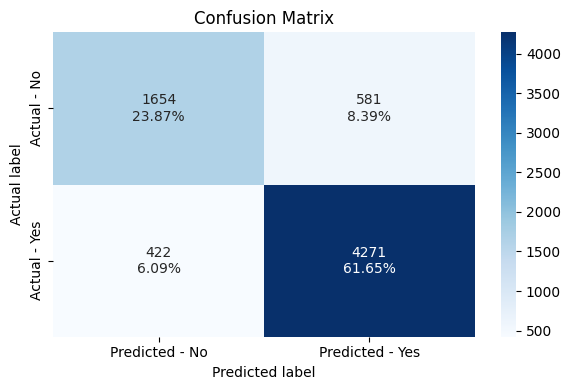

In [38]:
confusion_matrix_sklearn(estimator, X_train, y_train)

* The Recall has improved on the training set as compared to the initial model.

**Checking model performance on test set**

In [39]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)

decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.843939,0.898613,0.867943,0.883012


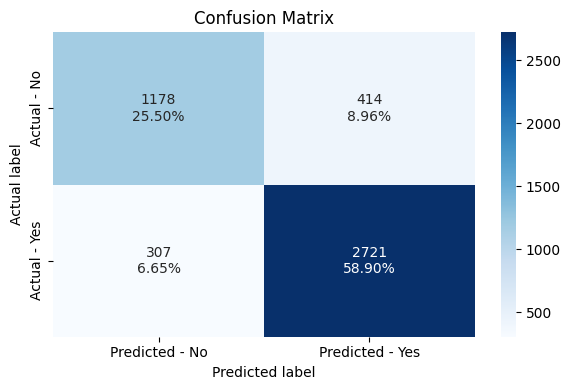

In [40]:
confusion_matrix_sklearn(estimator, X_test, y_test)

* After hyperparameter tuning the model has performance has remained same and the model has become simpler.

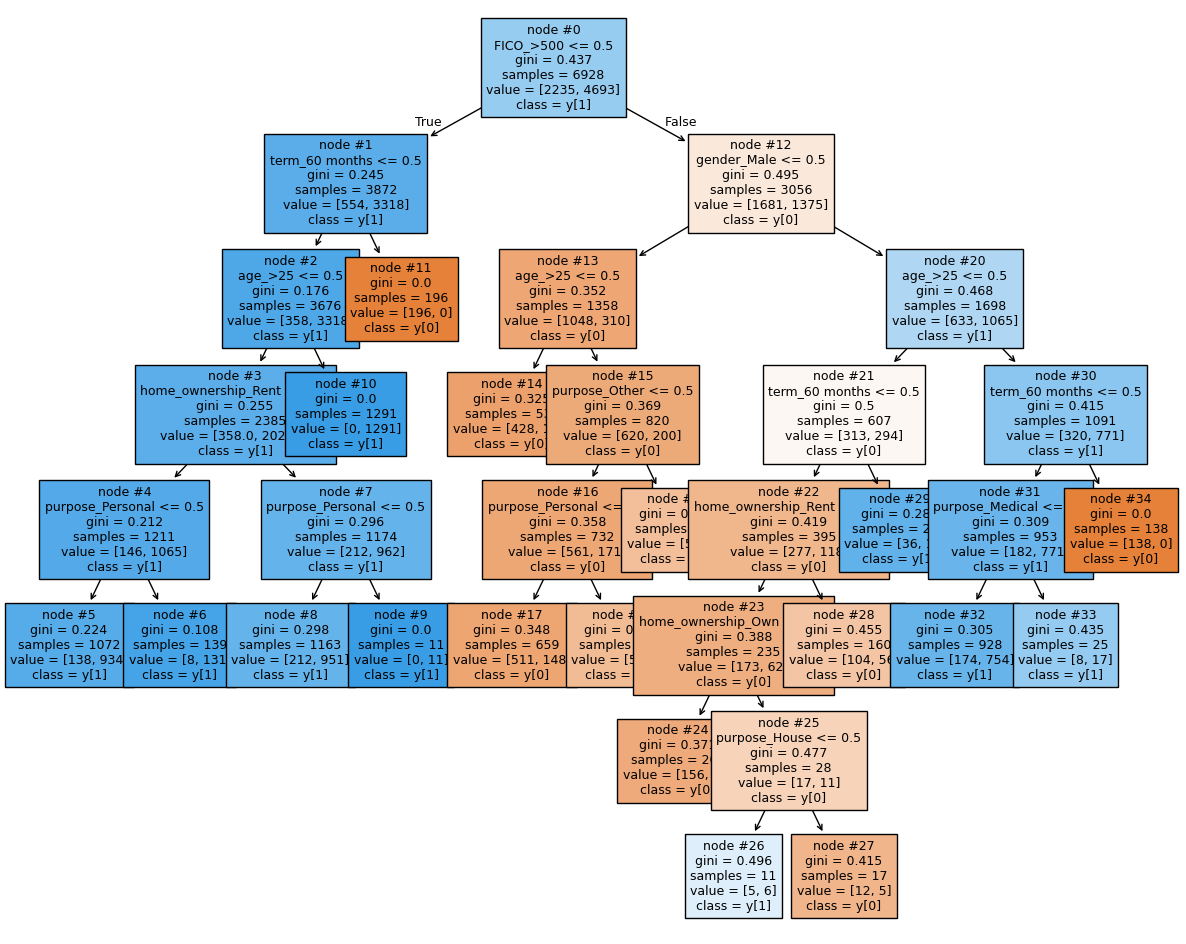

In [41]:
plt.figure(figsize=(15, 12))

tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
plt.show()

* We are getting a simplified tree after pre-pruning.

#### 3. Cost Complexity Pruning

In [42]:
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [43]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,0.226403
1,0.000000e+00,0.226403
2,2.794668e-09,0.226403
3,2.244984e-07,0.226403
4,4.918264e-07,0.226404
5,6.998390e-07,0.226404
6,7.597561e-07,0.226405
7,1.058874e-06,0.226406
8,1.184343e-06,0.226407
9,1.386119e-06,0.226409


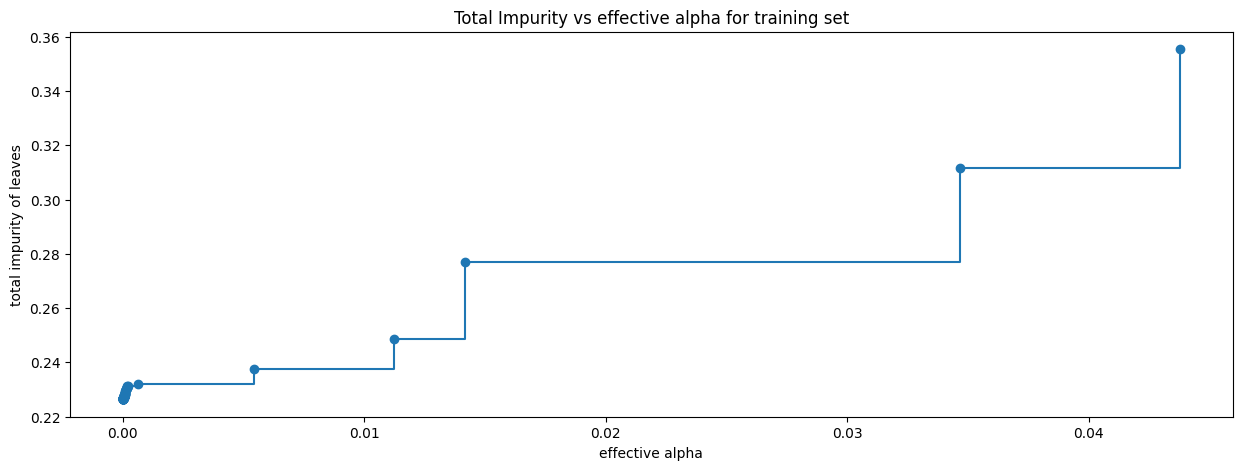

In [44]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using the effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [45]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.08167024657332106



For the remainder, we remove the last element in
``clfs`` and ``ccp_alphas``, because it is the trivial tree with only one
node. Here we show that the number of nodes and tree depth decreases as alpha
increases.

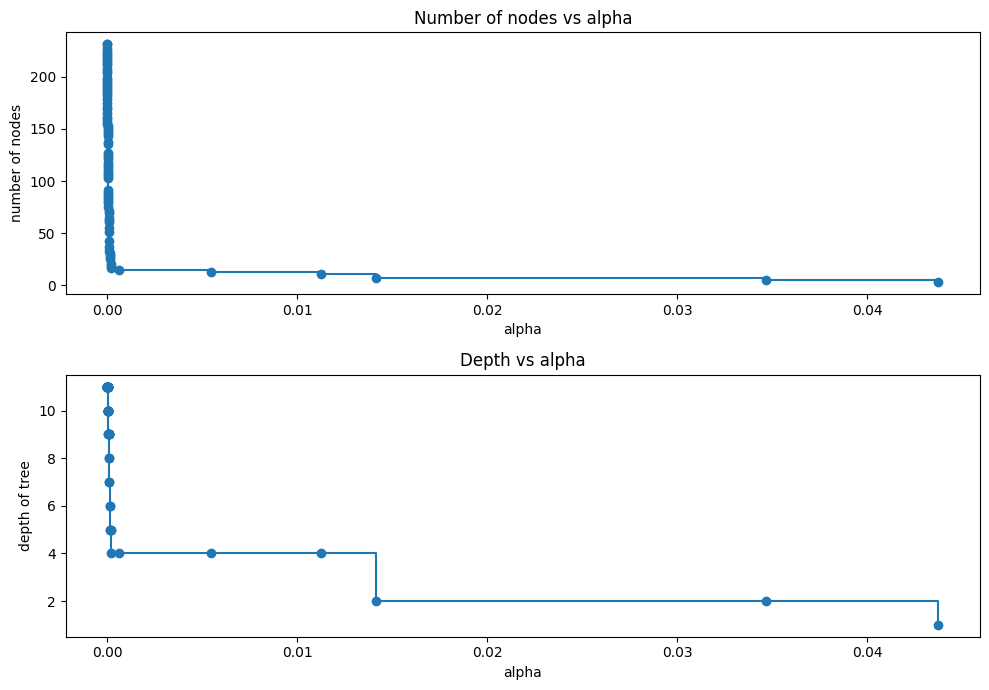

In [46]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

**Recall vs alpha for training and testing sets**

In [47]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [48]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

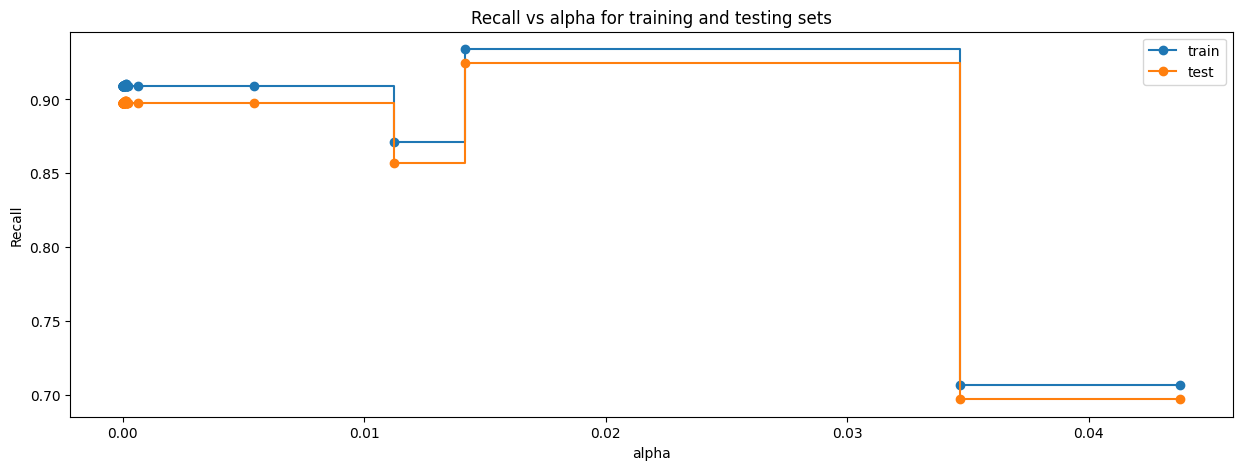

In [49]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [50]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.014171370928955346),
                       random_state=1)


**Checking model performance on training set**

In [51]:
decision_tree_postpruned_perf_train = model_performance_classification_sklearn(
    best_model, X_train, y_train
)
decision_tree_postpruned_perf_train

,Accuracy,Recall,Precision,F1
0,0.812211,0.933944,0.815594,0.870766


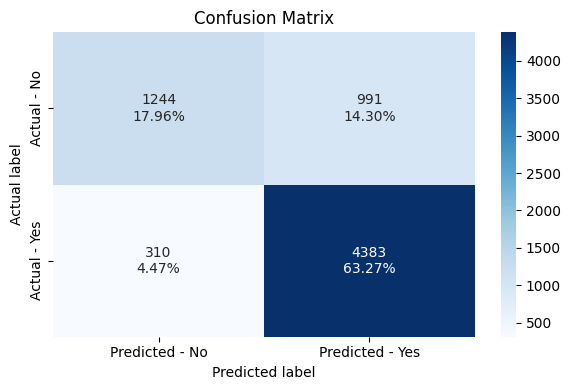

In [52]:
confusion_matrix_sklearn(best_model, X_train, y_train)

**Checking model performance on test set**

In [53]:
decision_tree_postpruned_perf_test = model_performance_classification_sklearn(
    best_model, X_test, y_test
)
decision_tree_postpruned_perf_test

,Accuracy,Recall,Precision,F1
0,0.798052,0.924703,0.798859,0.857187


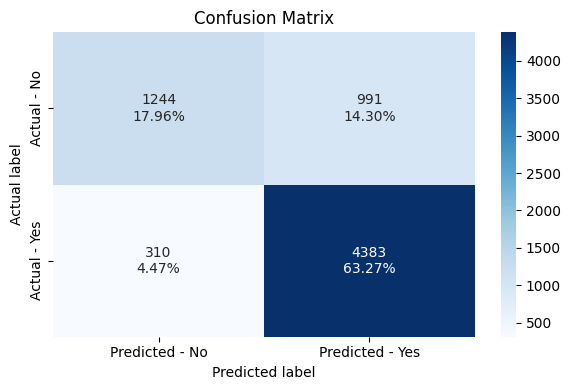

In [54]:
confusion_matrix_sklearn(best_model, X_train, y_train)

* With post-pruning we are getting good and generalized model performance on both training and test set.
* The recall has improved further.

**Visualizing the Decision Tree**

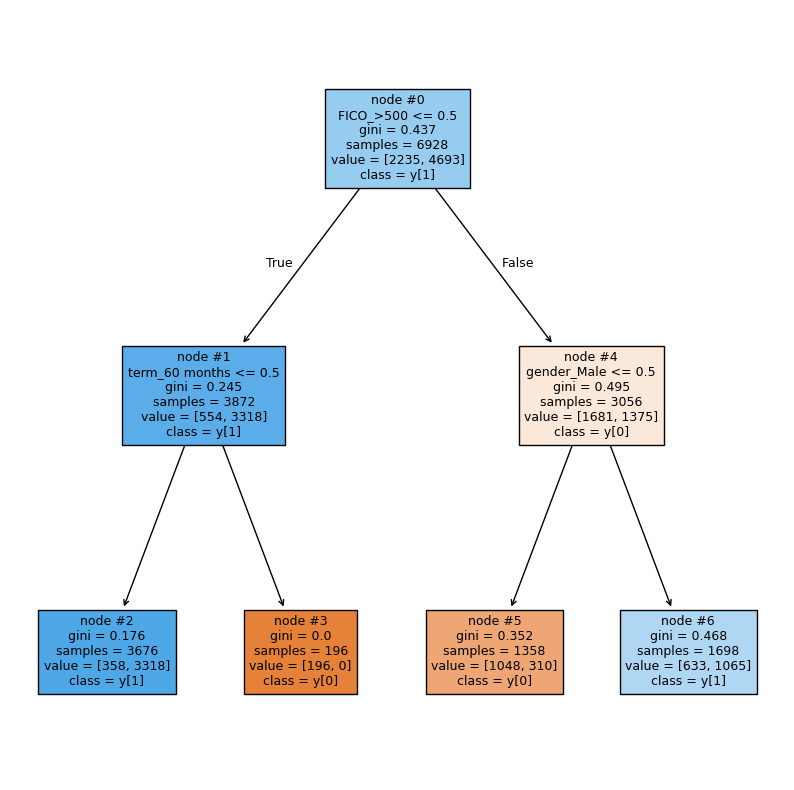

In [55]:
plt.figure(figsize=(10, 10))

out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()
plt.show()

In [56]:
# Text report showing the rules of a decision tree -

print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))

|--- FICO_>500 <= 0.50
|   |--- term_60 months <= 0.50
|   |   |--- weights: [358.00, 3318.00] class: 1
|   |--- term_60 months >  0.50
|   |   |--- weights: [196.00, 0.00] class: 0
|--- FICO_>500 >  0.50
|   |--- gender_Male <= 0.50
|   |   |--- weights: [1048.00, 310.00] class: 0
|   |--- gender_Male >  0.50
|   |   |--- weights: [633.00, 1065.00] class: 1



In [57]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the 'criterion' brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        best_model.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                          Imp
FICO_>500            0.510119
term_60 months       0.273355
gender_Male          0.216526
purpose_House        0.000000
purpose_Medical      0.000000
purpose_Other        0.000000
purpose_Personal     0.000000
purpose_Wedding      0.000000
home_ownership_Own   0.000000
home_ownership_Rent  0.000000
age_>25              0.000000


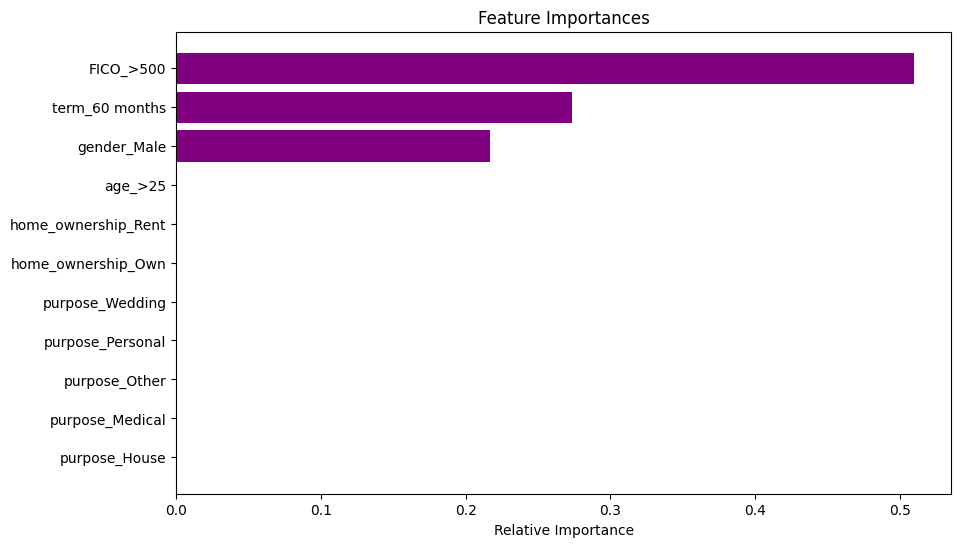

In [58]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="purple", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* FICO score, duration of the loan, and gender remain the most important feature with post-pruning too.

#### 4. Comparing all the decision tree models

In [59]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_postpruned_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree sklearn",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree sklearn,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.855514,0.855225,0.812211
Recall,0.908800,0.910079,0.933944
Precision,0.881563,0.880256,0.815594
F1,0.894974,0.894919,0.870766


In [60]:
# test performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_postpruned_perf_test.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree sklearn",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_train_comp_df

Test set performance comparison:


,Decision Tree sklearn,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.843723,0.843939,0.798052
Recall,0.897292,0.898613,0.924703
Precision,0.868606,0.867943,0.798859
F1,0.882716,0.883012,0.857187


* Decision tree with post-pruning is giving the highest recall on the test set.
* The tree with post pruning is not complex and easy to interpret.